# Classic model

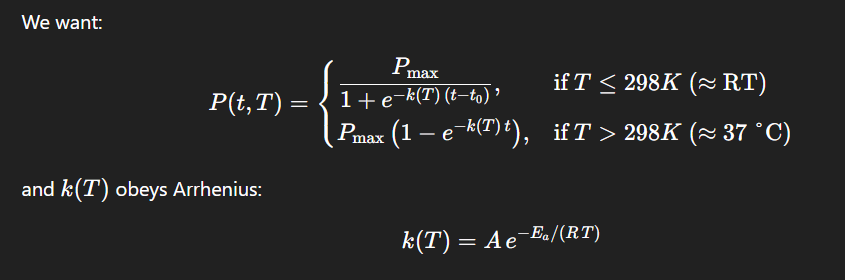

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

In [10]:
# --- Load your wide-format CSV ---
df_wide = pd.read_excel("all_time_temp.xlsx")

# Extract all experiment names automatically from column headers
samples = [col.split("_Time")[0] for col in df_wide.columns if "_Time" in col]

# Build dictionary {sample_name: sub-DataFrame}
datasets = {}
for s in samples:
    time_col = f"{s}_Time"
    temp_col = f"{s}_Temperature"
    subdf = df_wide[[time_col, temp_col]].copy()
    subdf.columns = ["Time (h)", "calibrated temperature (C)"]
    subdf = subdf.dropna().reset_index(drop=True)
    datasets[s] = subdf

print(" Loaded samples:", list(datasets.keys()))


✅ Loaded samples: ['M1_RT', 'M2_RT', 'M2_37C', 'M3_RT', 'M3_37C', 'M4_37C']


In [20]:

R = 8.314  # J/mol·K

# --- Cell 3: Metadata for each experiment ---

meta = pd.DataFrame({
    "Sample": ["M1_RT", "M2_RT", "M2_37C", "M3_RT", "M3_37C", "M4_37C"],
    "C_mM": [2.5, 2.18, 2.18, 1.2, 1.2, 1.6],
    "V_solution_mL": [6.0]*6,
    "V_head_mL": [4.0]*6,
    "Ea_Jmol": [19999.06, 19999.22, 93554.58,19997.88, 23583.23, 91914.18],  #check this
    "A_ph": [138.63, 178.49, 3.56e14, 252.38, 911.411, 2.45e14 ],  #check this
    "t0_h":[16.55, 62.77, 12.25, 29.25,7.16, 8.65],
    "Yield": [0.91, 0.756, 0.93, 0.902, 0.95, 0.97],
    "Model": ["logistic", "logistic", "first_order", "logistic", "first_order", "first_order"]
})

display(meta)










,Sample,C_mM,V_solution_mL,V_head_mL,Ea_Jmol,A_ph,t0_h,Yield,Model
0,M1_RT,2.50,6.0,4.0,19999.06,1.386300e+02,16.55,0.910,logistic
1,M2_RT,2.18,6.0,4.0,19999.22,1.784900e+02,62.77,0.756,logistic
2,M2_37C,2.18,6.0,4.0,93554.58,3.560000e+14,12.25,0.930,first_order
3,M3_RT,1.20,6.0,4.0,19997.88,2.523800e+02,29.25,0.902,logistic
4,M3_37C,1.20,6.0,4.0,23583.23,9.114110e+02,7.16,0.950,first_order
5,M4_37C,1.60,6.0,4.0,91914.18,2.450000e+14,8.65,0.970,first_order


In [21]:
# --- Cell 4: Compute dynamic k(T) for each sample --- i.e the arrhenius K
R = 8.314  # J/mol·K

k_dynamic = {}

for s in datasets.keys():
    df = datasets[s].copy()
    meta_row = meta.loc[meta["Sample"] == s].iloc[0]
    
    # convert °C → K
    df["T_K"] = df["calibrated temperature (C)"] + 273.15
    
    # dynamic k(t) using Arrhenius
    A = meta_row["A_ph"]
    Ea = meta_row["Ea_Jmol"]
    df["k(1/h)"] = A * np.exp(-Ea / (R * df["T_K"]))
    
    k_dynamic[s] = df
    print(f" Computed k(T) for {s}: range = [{df['k(1/h)'].min():.3e}, {df['k(1/h)'].max():.3e}]")


 Computed k(T) for M1_RT: range = [4.078e-02, 4.394e-02]
 Computed k(T) for M2_RT: range = [5.323e-02, 5.731e-02]
 Computed k(T) for M2_37C: range = [5.452e-02, 5.725e-02]
 Computed k(T) for M3_RT: range = [7.694e-02, 8.961e-02]
 Computed k(T) for M3_37C: range = [9.603e-02, 9.704e-02]
 Computed k(T) for M4_37C: range = [7.856e-02, 8.373e-02]


In [22]:
# Pmax for each sample


Pmax_dict = {}

for s in meta["Sample"]:
    m = meta.loc[meta["Sample"] == s].iloc[0]
    
    # Convert concentration from mM → mol/L
    C_mol_L = m["C_mM"] * 1e-3
    
    # Convert volumes to liters and cubic meters
    V_sol_L = m["V_solution_mL"] * 1e-3
    V_head_L = m["V_head_mL"] * 1e-3
    V_head_m3 = V_head_L * 1e-3  # 1 L = 1e-3 m³
    
    # Use the mean temperature from your dynamic data
    df_temp = datasets[s]
    T_mean_K = (df_temp["calibrated temperature (C)"].mean() + 273.15)
    
    # Calculate moles of O₂ released
    n_mol = C_mol_L * V_sol_L * m["Yield"]
    
    # Ideal gas law: P = nRT / V
    Pmax_Pa = (n_mol * R * T_mean_K) / V_head_m3
    Pmax_kPa = Pmax_Pa / 1000.0
    
    Pmax_dict[s] = Pmax_kPa
    print(f"{s}: Pmax = {Pmax_kPa:.2f} kPa (T_mean = {T_mean_K:.2f} K)")



M1_RT: Pmax = 8.42 kPa (T_mean = 296.78 K)
M2_RT: Pmax = 6.12 kPa (T_mean = 297.62 K)
M2_37C: Pmax = 7.82 kPa (T_mean = 309.31 K)
M3_RT: Pmax = 4.04 kPa (T_mean = 299.62 K)
M3_37C: Pmax = 4.41 kPa (T_mean = 309.98 K)
M4_37C: Pmax = 6.00 kPa (T_mean = 310.04 K)


In [23]:
# --- Cell 6: Simulate P(t) for each sample --- (pressure at each time point)

from scipy.integrate import cumulative_trapezoid

results = {}

for s in datasets.keys():
    df = k_dynamic[s]
    m = meta.loc[meta["Sample"] == s].iloc[0]
    
    time = df["Time (h)"].values
    kT = df["k(1/h)"].values
    Pmax = Pmax_dict[s]
    
    if m["Model"] == "logistic":
        # Logistic growth: P = Pmax / (1 + exp(-∫k dt))
        t0 = m["t0_h"]
        K_int = cumulative_trapezoid(kT, time, initial=0)
        P = Pmax / (1 + np.exp(-K_int*(time - t0)))
        
    elif m["Model"] == "first_order":
        # First-order release: P = Pmax * (1 - exp(-∫k dt))
        K_int = cumulative_trapezoid(kT, time, initial=0)
        P = Pmax * (1 - np.exp(-K_int))
        
    else:
        raise ValueError(f"Unknown model type for {s}")
    
    df["P_predicted"] = P
    results[s] = df

    print(f" Simulated P(t) for {s} ({m['Model']})")


 Simulated P(t) for M1_RT (logistic)
 Simulated P(t) for M2_RT (logistic)
 Simulated P(t) for M2_37C (first_order)
 Simulated P(t) for M3_RT (logistic)
 Simulated P(t) for M3_37C (first_order)
 Simulated P(t) for M4_37C (first_order)


In [ ]:
# --- Cell 7: Plot ---
import matplotlib.pyplot as plt

for s, df in results.items():
    m = meta.loc[meta["Sample"] == s].iloc[0]
    plt.figure(figsize=(6,4))
    plt.plot(df["Time (h)"], df["P_predicted"], label=f"{s} ({m['Model']})", lw=2)
    plt.xlabel("Time (h)")
    plt.ylabel("Predicted Pressure / O₂ released (relative)")
    plt.title(f"Classical model prediction — {s}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# --- constants ---
R = 8.314  # J/mol·K

# --- helper to choose nearest kinetic parameters ---
def get_params_for_temp(temp_C, meta):
    """
    Select the nearest experiment's A and Ea from the meta DataFrame
    based on user temperature (Celsius).
    """
    # Define representative mean temperatures for each model
    # (You could also store actual mean T in meta if available)
    model_temp_map = {
        "logistic": 25.0,
        "first_order": 37.0
    }

    # Compute distance of user temperature from each model type
    d_logistic = abs(temp_C - model_temp_map["logistic"])
    d_first = abs(temp_C - model_temp_map["first_order"])

    # Choose the closest model type
    model_type = "logistic" if d_logistic < d_first else "first_order"

    # Get the row from your real meta table
    row = meta[meta["Model"] == model_type].iloc[0]
    A = row["A_ph"]
    Ea = row["Ea_Jmol"]
    return A, Ea, model_type




def simulate_classical(conc_mM, temp_C):
    # 1️⃣ Automatically choose parameters based on temperature
    A, Ea, model_choice = get_params_for_temp(temp_C, meta)

    # 2️⃣ Interpolate t0 based on temp
    t0_rt = meta.loc[meta["Model"] == "logistic", "t0_h"].mean()   # RT mean
    t0_37 = meta.loc[meta["Model"] == "first_order", "t0_h"].mean()  # 37C mean
    t0 = np.interp(temp_C, [25, 37], [t0_rt, t0_37])

    # 3️⃣ Fixed geometry
    V_sol_L = 0.006   # 6 mL solution
    V_head_L = 0.004  # 4 mL headspace
    Yield = 0.9

    # 4️⃣ Unit conversions
    C_mol_L = conc_mM * 1e-3
    T_K = temp_C + 273.15
    V_head_m3 = V_head_L * 1e-3

    # 5️⃣ Arrhenius rate constant
    k = A * np.exp(-Ea / (R * T_K))  # 1/h

    # 6️⃣ Compute Pmax in kPa
    n_mol = C_mol_L * V_sol_L * Yield
    Pmax_Pa = (n_mol * R * T_K) / V_head_m3
    Pmax_kPa = Pmax_Pa / 1000.0

    # 7️⃣ Simulate P(t)
    t = np.linspace(0, 150, 400)
    k_vis = k * 1.5
    if model_choice == "logistic":
        P = Pmax_kPa / (1 + np.exp(-k_vis * (t - t0)))
    else:
        P = Pmax_kPa * (1 - np.exp(-k * t))

    # 8️⃣ Convert Pressure → µmol O₂
    R_Latm = 0.082057  # L·atm/mol·K
    pressure_atm = P / 101.325  # convert kPa → atm
    o2_umol = ((pressure_atm * V_head_L) / (R_Latm * T_K)) * 1e6  # µmol O₂

    # optional ratio (for normalization if needed)
    ratio = V_sol_L / V_head_L

    # 9️⃣ Plot both Pressure and O₂ on two axes
    fig, ax1 = plt.subplots(figsize=(7, 4))
    ax1.plot(t, P, lw=2, color="tab:blue", label="Pressure (kPa)")
    ax1.set_xlabel("Time (h)")
    ax1.set_ylabel("Pressure (kPa)", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    ax2 = ax1.twinx()
    ax2.plot(t, o2_umol, lw=2, color="tab:red", linestyle="--", label="O₂ released (µmol)")
    ax2.set_ylabel("O₂ released (µmol)", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    plt.title(f"Predicted P(t) and O₂(t) — {model_choice.capitalize()} model @ {temp_C:.1f}°C")
    fig.tight_layout()
    plt.show()

    # 10️⃣ Print key summary
    print(f"Model selected: {model_choice}")
    print(f"A = {A:.3e}, Ea = {Ea/1000:.1f} kJ/mol, t₀ = {t0:.2f} h")
    print(f"k(T) = {k:.3e} 1/h, Pmax = {Pmax_kPa:.2f} kPa")
    print(f"Predicted max O₂ = {max(o2_umol):.2f} µmol (ratio sol/head = {ratio:.2f})")
    
    # --- interactive sliders ---
interact(
    simulate_classical,
    conc_mM=FloatSlider(value=2.0, min=0.5, max=5.0, step=0.1, description="Conc (mM)"),
    temp_C=FloatSlider(value=25.0, min=20.0, max=45.0, step=0.5, description="Temp (°C)")
);


interactive(children=(FloatSlider(value=2.0, description='Conc (mM)', max=5.0, min=0.5), FloatSlider(value=25.…

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ipywidgets import interact, FloatSlider

# R = 8.314  # J/mol·K

# # --- Smooth blending function ---
# def logistic_weight(temp_C, conc_mM):
#     """
#     Returns weight w ∈ [0,1] for logistic contribution based on T and concentration.
#     Lower T, higher conc → more logistic.
#     """
#     # center around 31°C midpoint between RT and 37°C
#     temp_effect = 1 - 1/(1 + np.exp(-(30 - temp_C)/1.5))  # logistic transition in T
#     conc_effect = 1/(1 + np.exp(-(conc_mM - 1.8)/0.3))    # stronger logistic for higher conc
#     w = (conc_effect * (1 - temp_effect))  # combine effects
#     return np.clip(w, 0, 1)

# # --- Get parameters smoothly from meta table ---
# def get_params_interpolated(temp_C, meta):
#     """
#     Interpolates A and Ea based on temperature between RT (logistic) and 37C (first-order).
#     """
#     A_rt = meta.loc[meta["Model"] == "logistic", "A_ph"].mean()
#     Ea_rt = meta.loc[meta["Model"] == "logistic", "Ea_Jmol"].mean()
#     A_37 = meta.loc[meta["Model"] == "first_order", "A_ph"].mean()
#     Ea_37 = meta.loc[meta["Model"] == "first_order", "Ea_Jmol"].mean()

#     A = np.interp(temp_C, [25, 37], [A_rt, A_37])
#     Ea = np.interp(temp_C, [25, 37], [Ea_rt, Ea_37])
#     return A, Ea

# # --- Simulator ---
# def simulate_classical(conc_mM, temp_C):
#     A, Ea = get_params_interpolated(temp_C, meta)
#     w_logistic = logistic_weight(temp_C, conc_mM)  # smooth transition weight

#     # geometry
#     V_sol_L = 0.006
#     V_head_L = 0.004
#     Yield = 0.9

#     C_mol_L = conc_mM * 1e-3
#     T_K = temp_C + 273.15
#     V_head_m3 = V_head_L * 1e-3

#     # --- Compute Arrhenius safely ---
#     Ea_over_RT = Ea / (R * T_K)
#     Ea_over_RT = np.clip(Ea_over_RT, -100, 100)  # prevent exp overflow
#     k = A * np.exp(-Ea_over_RT)

#     # --- Bound k physically (to avoid step-like explosions) ---
#     k = np.clip(k, 1e-5, 0.3)  # realistic range ~10⁻⁵–0.3 h⁻¹ for your system
#     n_mol = C_mol_L * V_sol_L * Yield
#     Pmax_kPa = (n_mol * R * T_K) / V_head_m3 / 1000.0

#     # t0 interpolated between RT and 37°C values
#     t0_rt = meta.loc[meta["Model"] == "logistic", "t0_h"].mean()
#     t0_37 = meta.loc[meta["Model"] == "first_order", "t0_h"].mean()
#     t0 = np.interp(temp_C, [25, 37], [t0_rt, t0_37])

#     t = np.linspace(0, 150, 400)
 
#     exp_term = np.exp(np.clip(-k * (t - t0), -60, 60))  # stable exp
#     P_logistic = Pmax_kPa / (1 + exp_term)
#     P_first = Pmax_kPa * (1 - np.exp(np.clip(-k * t, -60, 60)))
#     P = w_logistic * P_logistic + (1 - w_logistic) * P_first

#     # O₂ conversion
#     R_Latm = 0.082057
#     pressure_atm = P / 101.325
#     o2_umol = ((pressure_atm * V_head_L) / (R_Latm * T_K)) * 1e6

#     # plot
#     fig, ax1 = plt.subplots(figsize=(7, 4))
#     ax1.plot(t, P, lw=2, color="tab:blue", label=f"P(t)")
#     ax1.set_xlabel("Time (h)")
#     ax1.set_ylabel("Pressure (kPa)", color="tab:blue")
#     ax1.tick_params(axis="y", labelcolor="tab:blue")

#     ax2 = ax1.twinx()
#     ax2.plot(t, o2_umol, lw=2, color="tab:red", linestyle="--", label="O₂ released (µmol)")
#     ax2.set_ylabel("O₂ released (µmol)", color="tab:red")
#     ax2.tick_params(axis="y", labelcolor="tab:red")

#     plt.title(f"Predicted P(t) and O₂(t) — Weighted Logistic/First-Order @ {temp_C:.1f}°C")
#     fig.tight_layout()
#     plt.show()

#     print(f"w_logistic = {w_logistic:.2f} → {w_logistic*100:.1f}% logistic, {(1-w_logistic)*100:.1f}% first-order")
#     print(f"A = {A:.3e}, Ea = {Ea/1000:.1f} kJ/mol, k(T) = {k:.3e} 1/h, t₀ = {t0:.2f} h, Pmax = {Pmax_kPa:.2f} kPa")
#     print(f"Predicted max O₂ = {max(o2_umol):.2f} µmol")

# interact(
#     simulate_classical,
#     conc_mM=FloatSlider(value=2.0, min=0.5, max=5.0, step=0.1, description="Conc (mM)"),
#     temp_C=FloatSlider(value=25.0, min=20.0, max=45.0, step=0.5, description="Temp (°C)")
);


interactive(children=(FloatSlider(value=2.0, description='Conc (mM)', max=5.0, min=0.5), FloatSlider(value=25.…